# Skip warnings.

In [94]:
# -------------------------------
# Suppress common warnings
# -------------------------------

import warnings
warnings.filterwarnings("ignore")

# Suppress sklearn convergence warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Suppress matplotlib user warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Suppress pandas future warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Optional: suppress seaborn warnings
warnings.filterwarnings("ignore", module="seaborn")


# 1. Install & import all libraries

In [95]:
# ==============================
# INSTALL REQUIRED LIBRARIES
# ==============================
!pip install pandas numpy matplotlib seaborn scikit-learn scipy statsmodels shap
!pip install missingno



In [96]:

# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import missingno as msno
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


In [97]:
#/BASE_DIR = "IQ3_outputs"
##PLOT_DIR = os.path.join(BASE_DIR, "plots")
##CSV_DIR = os.path.join(BASE_DIR, "csvs")

##os.makedirs(PLOT_DIR, exist_ok=True)
##os.makedirs(CSV_DIR, exist_ok=True)


# 2. Upload dataset.*italicized text*

In [98]:
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding='latin1')

Saving R1_dataset.csv to R1_dataset (2).csv


# 3. Check for nulls.


In [99]:
uploaded = {'R1_dataset.csv': b''}
df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')

print(f"DataFrame has {df.shape[1]} columns.")

# Remove unwanted index column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Rename columns
df.columns = [
    "ID", "IQ1_Gender", "IQ2_Age", "IQ3_OutOfStock",
    "IQ4_QualityVsPrice", "IQ5_BrandLoyalty",
    "IQ6_SameBrand"
]

# Check missing values
print("Are there any missing values in the dataset?", df.isnull().values.any())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

DataFrame has 8 columns.
Are there any missing values in the dataset? True

Missing values per column:
ID                    48
IQ1_Gender            47
IQ2_Age               47
IQ3_OutOfStock        47
IQ4_QualityVsPrice    47
IQ5_BrandLoyalty      47
IQ6_SameBrand         47
dtype: int64

Total missing values: 330


<Figure size 1000x600 with 0 Axes>

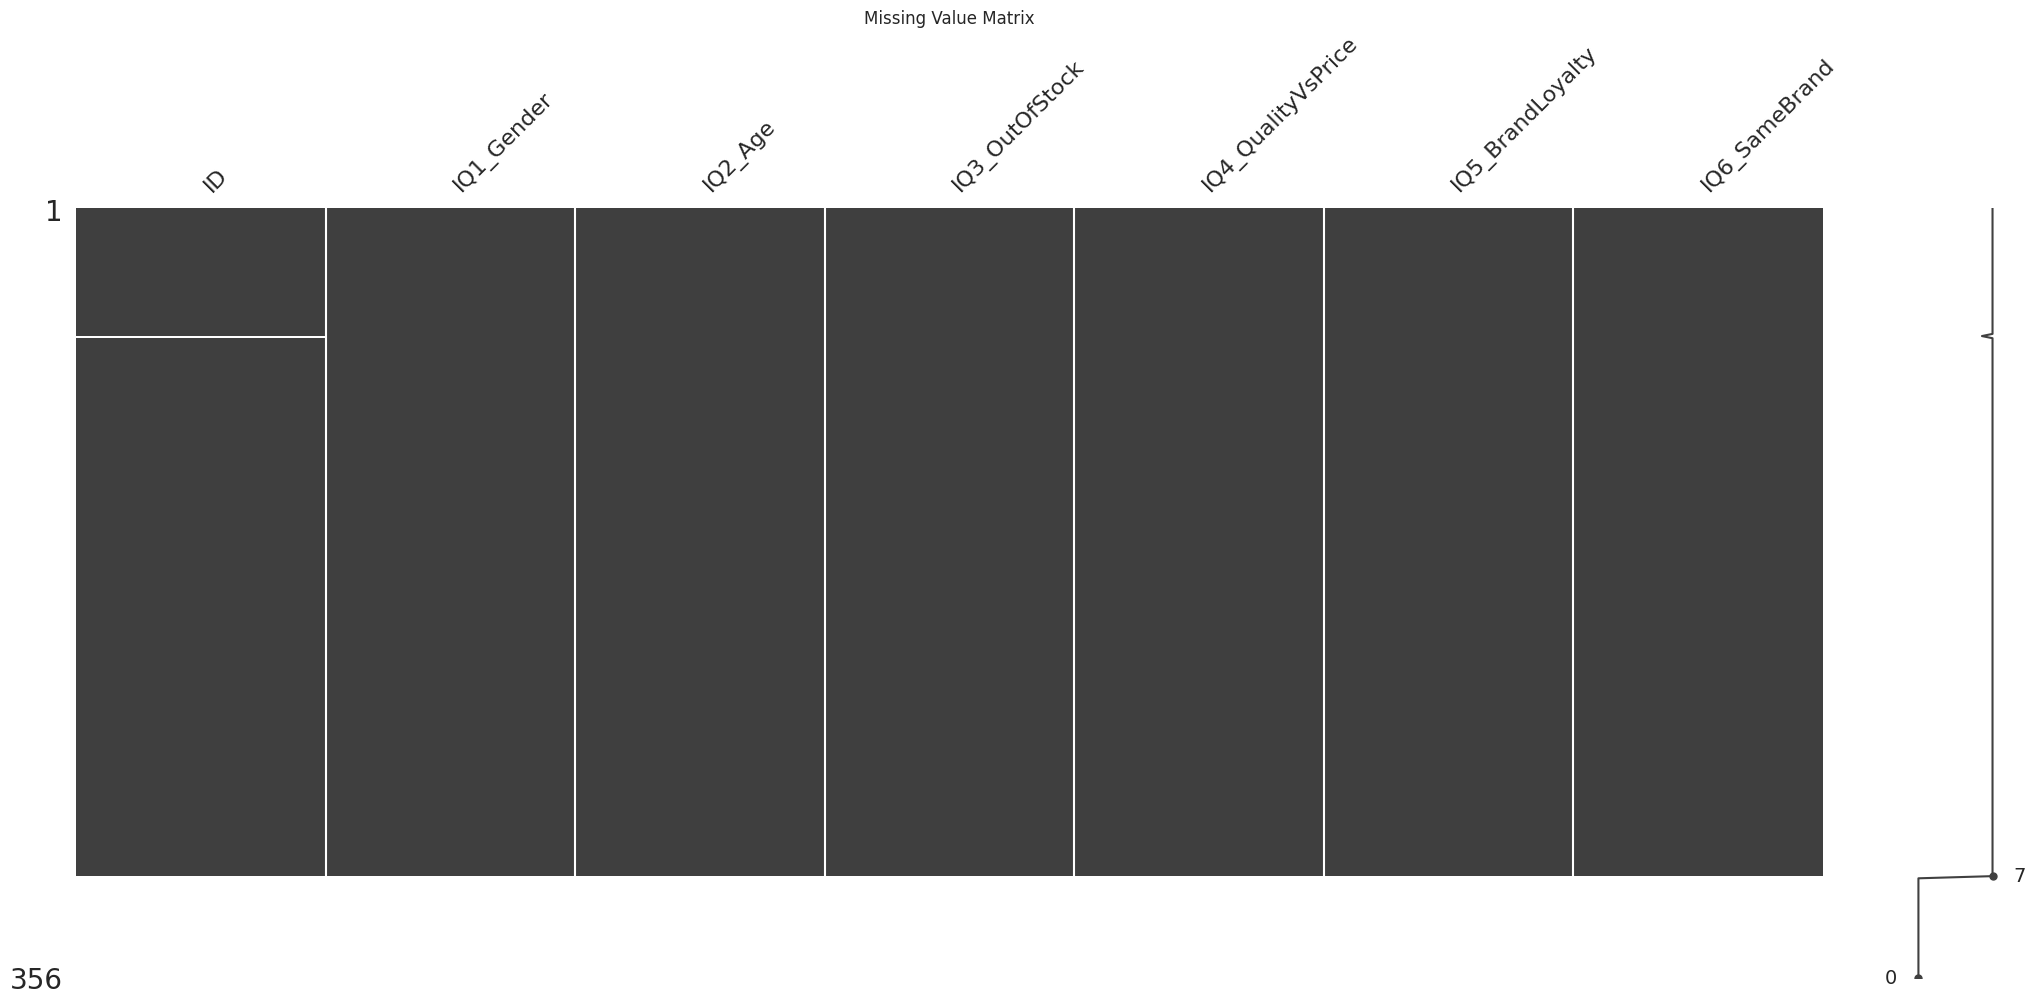

In [100]:
plt.figure(figsize=(10,6))
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

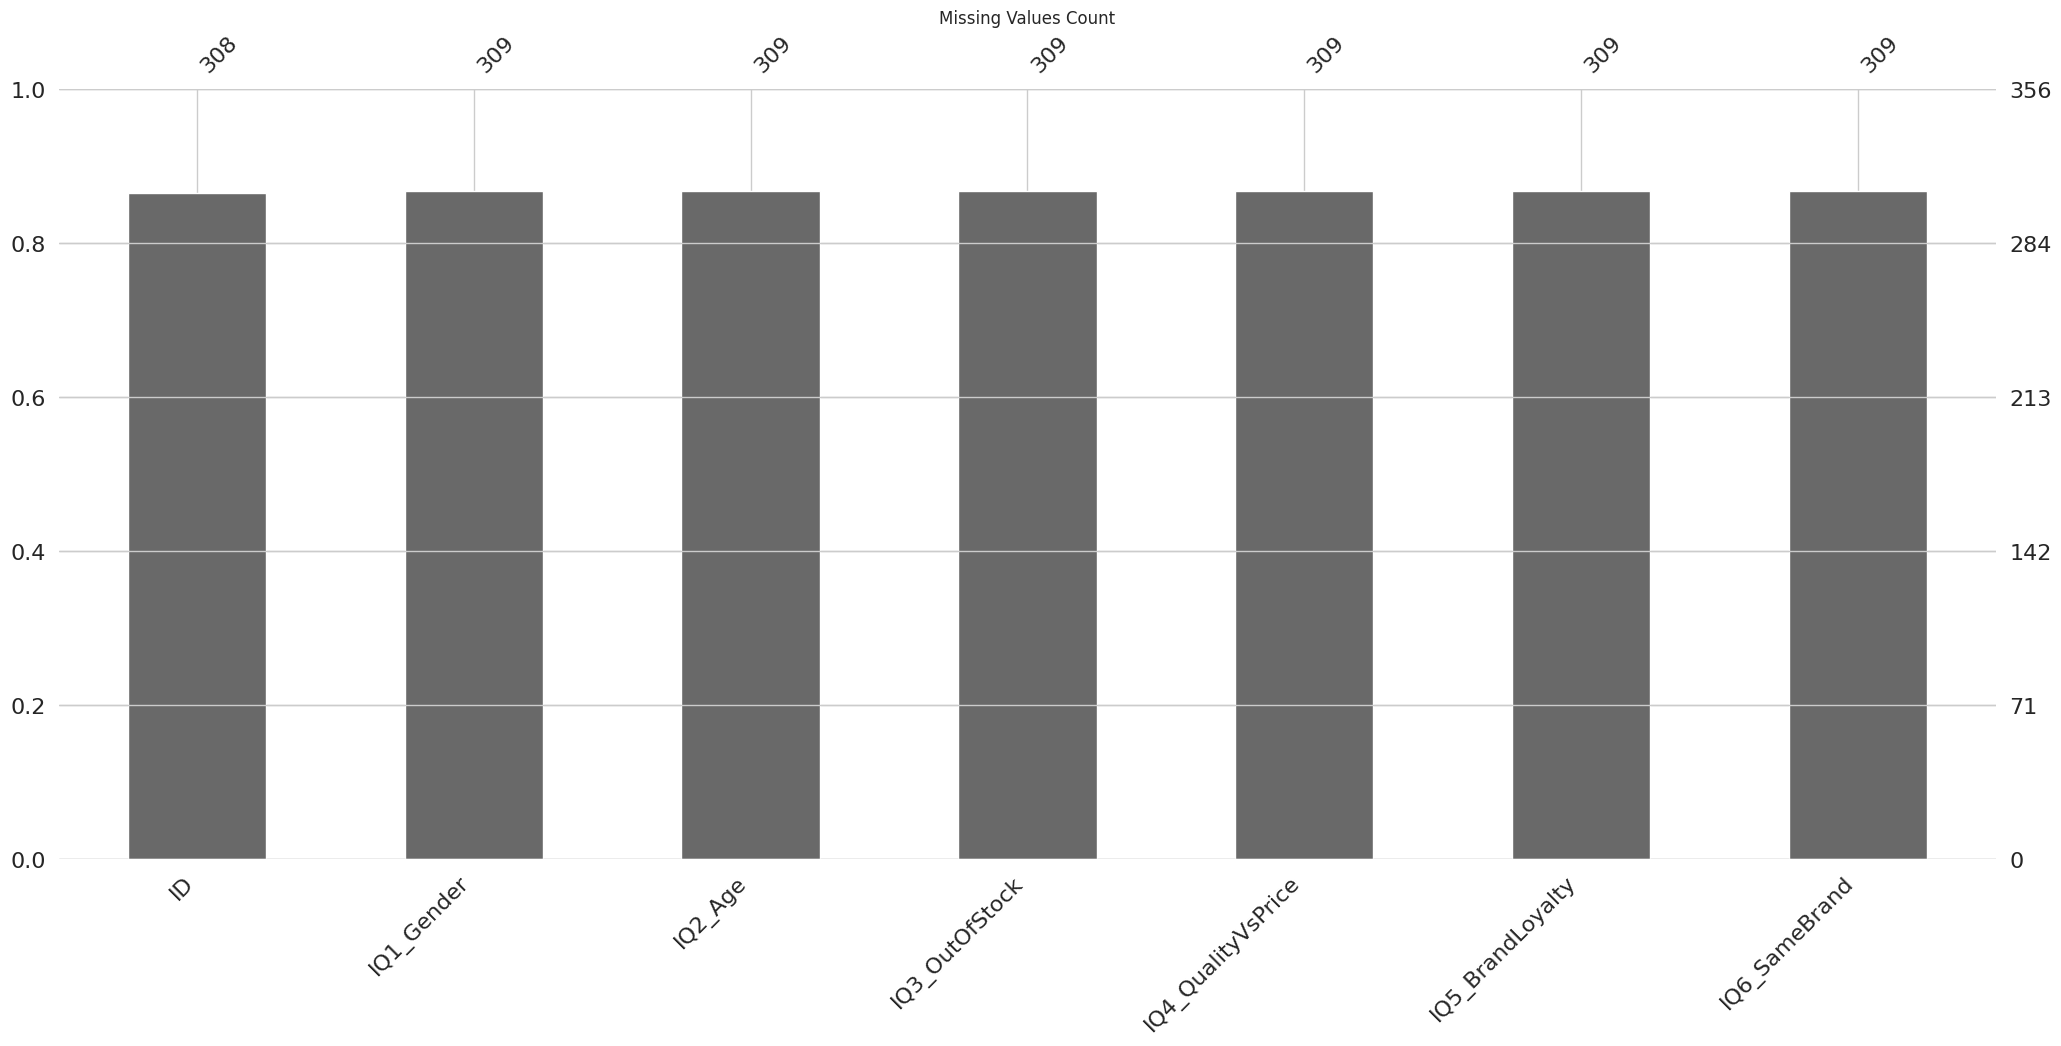

In [101]:
plt.figure(figsize=(10,6))
msno.bar(df)
plt.title("Missing Values Count")
plt.show()

In [102]:
# Fill missing value in IQ4_QualityVsPrice with mode
df['IQ4_QualityVsPrice'].fillna(df['IQ4_QualityVsPrice'].mode()[0], inplace=True)

In [103]:
df['ID'].fillna(df['ID'].max() + 1, inplace=True)

In [104]:
print("\nFinal missing value check:")
print(df.isnull().sum())


Final missing value check:
ID                     0
IQ1_Gender            47
IQ2_Age               47
IQ3_OutOfStock        47
IQ4_QualityVsPrice     0
IQ5_BrandLoyalty      47
IQ6_SameBrand         47
dtype: int64


# 4. HEADS & TAILS.


In [105]:
import pandas as pd

# If you already have the dataset loaded as df, skip reading it
# df = pd.read_csv('your_file.csv')

# Display first 5 rows (HEAD)
print("HEAD of the dataset:")
print(df.head())

# Display last 5 rows (TAIL)
print("\nTAIL of the dataset:")
print(df.tail())


HEAD of the dataset:
     ID  IQ1_Gender  IQ2_Age  IQ3_OutOfStock IQ4_QualityVsPrice  \
0  22.0         2.0      3.0             4.0                  4   
1  55.0         2.0      2.0             5.0                  5   
2  23.0         2.0      1.0             4.0                  4   
3  18.0         1.0      1.0             4.0                  4   
4  57.0         1.0      2.0             3.0                  4   

   IQ5_BrandLoyalty  IQ6_SameBrand  
0               4.0            2.0  
1               5.0            1.0  
2               4.0            2.0  
3               5.0            1.0  
4               5.0            2.0  

TAIL of the dataset:
       ID  IQ1_Gender  IQ2_Age  IQ3_OutOfStock IQ4_QualityVsPrice  \
351  68.0         NaN      NaN             NaN                  5   
352  68.0         NaN      NaN             NaN                  5   
353  68.0         NaN      NaN             NaN                  5   
354  68.0         NaN      NaN             NaN          

### 5. Load & clean dataset

In [106]:
import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')

# Remove any automatically created index column
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Now rename columns (7 columns remaining)
df.columns = [
    "ID",
    "IQ1_Gender",
    "IQ2_Age",
    "IQ3_OutOfStock",
    "IQ4_QualityVsPrice",
    "IQ5_BrandLoyalty",
    "IQ6_SameBrand"
]

# Save cleaned dataset
df.to_csv("cleaned_dataset.csv", index=False)

df.head(), df.tail()

(     ID  IQ1_Gender  IQ2_Age  IQ3_OutOfStock IQ4_QualityVsPrice  \
 0  22.0         2.0      3.0             4.0                  4   
 1  55.0         2.0      2.0             5.0                  5   
 2  23.0         2.0      1.0             4.0                  4   
 3  18.0         1.0      1.0             4.0                  4   
 4  57.0         1.0      2.0             3.0                  4   
 
    IQ5_BrandLoyalty  IQ6_SameBrand  
 0               4.0            2.0  
 1               5.0            1.0  
 2               4.0            2.0  
 3               5.0            1.0  
 4               5.0            2.0  ,
      ID  IQ1_Gender  IQ2_Age  IQ3_OutOfStock IQ4_QualityVsPrice  \
 351 NaN         NaN      NaN             NaN                NaN   
 352 NaN         NaN      NaN             NaN                NaN   
 353 NaN         NaN      NaN             NaN                NaN   
 354 NaN         NaN      NaN             NaN                NaN   
 355 NaN         NaN 

## 6. Exploratory Data Analysis (EDA)

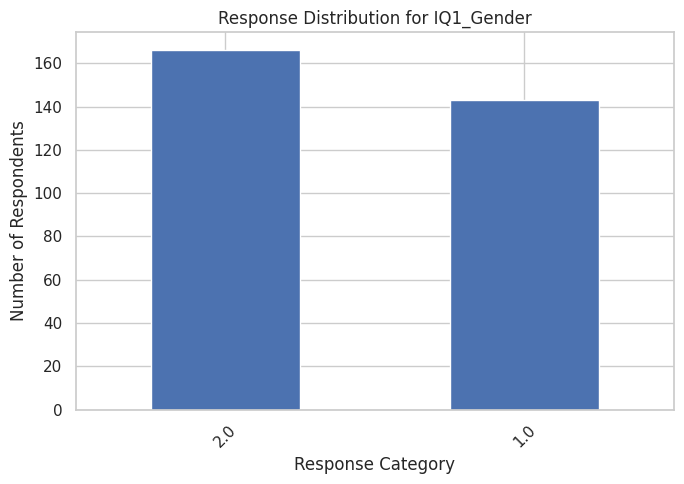

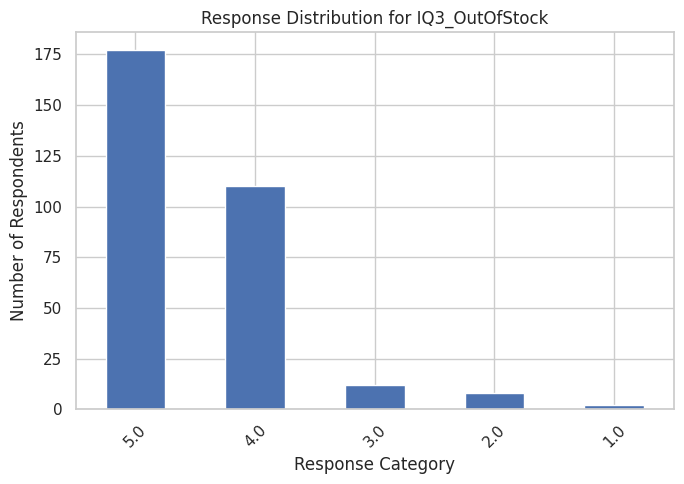

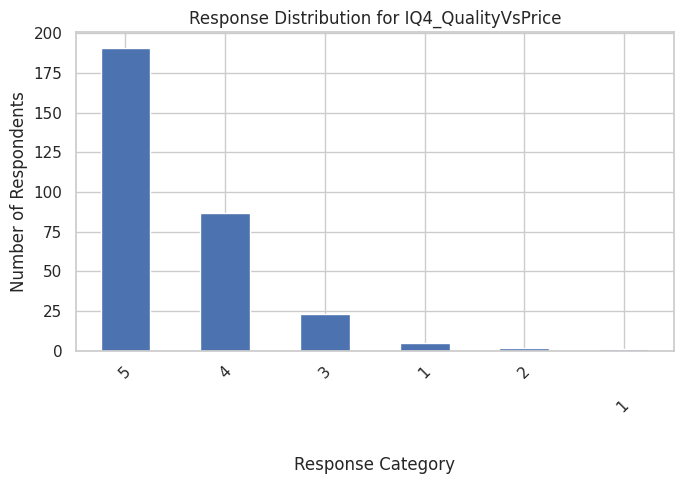

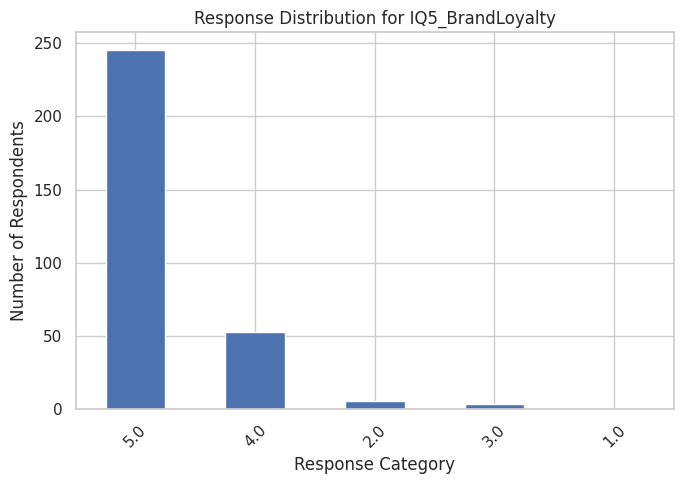

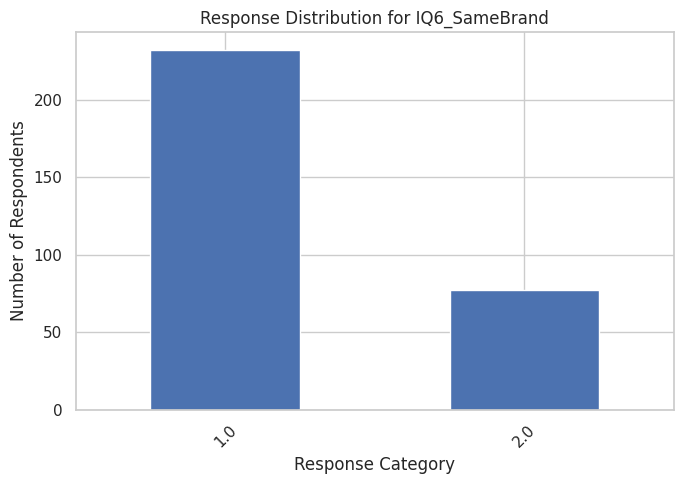

KeyError: 'IQ7_TryNewProduct'

<Figure size 700x500 with 0 Axes>

In [108]:
import matplotlib.pyplot as plt

os.makedirs("EDA_Plots", exist_ok=True)

categorical_cols = [
    'IQ1_Gender', 'IQ3_OutOfStock', 'IQ4_QualityVsPrice', 'IQ5_BrandLoyalty',
    'IQ6_SameBrand', 'IQ7_TryNewProduct', 'IQ8_Substitute', 'IQ9_BrandVsGeneric'
]

for col in categorical_cols:
    plt.figure(figsize=(7,5))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Response Distribution for {col}")
    plt.xlabel("Response Category")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.savefig(f"EDA_Plots/{col}_frequency.png")
    plt.close()

In [109]:
print('IQ7_TryNewProduct' in df.columns)

False


In [110]:
print(categorical_cols)

['IQ1_Gender', 'IQ3_OutOfStock', 'IQ4_QualityVsPrice', 'IQ5_BrandLoyalty', 'IQ6_SameBrand', 'IQ7_TryNewProduct', 'IQ8_Substitute', 'IQ9_BrandVsGeneric']


## 7. Target Variable Distribution (IQ3)

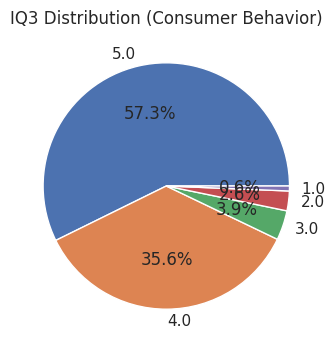

In [111]:
plt.figure(figsize=(6,4))
df['IQ3_OutOfStock'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("IQ3 Distribution (Consumer Behavior)")
plt.ylabel("")

plt.show()   # 👈 SHOWS THE PIE CHART

plt.savefig("EDA_Plots/IQ3_pie.png", bbox_inches='tight')
plt.close()


## 8. Chi-Square Dependency Tests (IQ3 vs Others)

In [112]:
chi_square_results = []

for col in df.columns:
    if col != 'IQ3_OutOfStock':
        contingency = pd.crosstab(df[col], df['IQ3_OutOfStock'])
        chi2, p, dof, _ = chi2_contingency(contingency)
        chi_square_results.append([col, chi2, p])

chi_df = pd.DataFrame(
    chi_square_results,
    columns=["Variable", "Chi-Square Statistic", "P-Value"]
)

chi_df

,Variable,Chi-Square Statistic,P-Value
0,ID,163.918462,8.537017e-01
1,IQ1_Gender,10.155178,3.789330e-02
2,IQ2_Age,16.233497,3.915741e-02
3,IQ4_QualityVsPrice,74.436956,3.380821e-08
4,IQ5_BrandLoyalty,89.177884,3.544636e-12
5,IQ6_SameBrand,13.915828,7.568602e-03


## 9. Preprocessing (Encoding)

In [113]:
df_encoded = df.copy()
encoder = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])


## 10. Feature / Target Split

In [114]:
X = df_encoded.drop(columns=['IQ3_OutOfStock'])
y = df_encoded['IQ3_OutOfStock']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## 10.Multinomial Logistic Regression

In [115]:
log_model = LogisticRegression(multi_class='multinomial', max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_report = classification_report(y_test, y_pred_log, output_dict=True)
pd.DataFrame(log_report).to_csv("logistic_regression_report.csv")


## 11. Decision Tree (Rules Visualization)

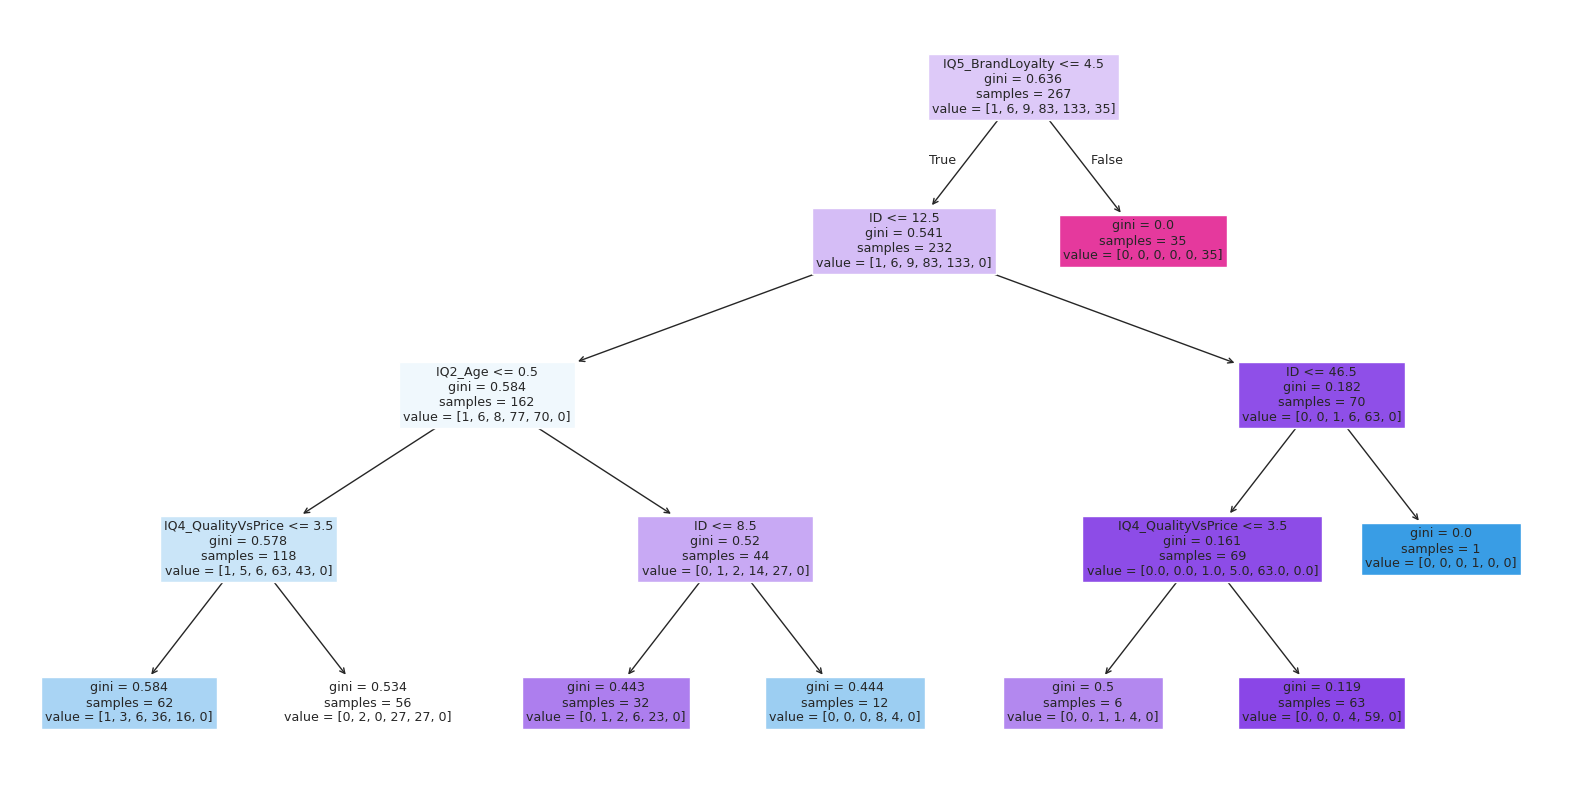

In [116]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(tree_model, feature_names=X.columns, filled=True)
plt.show()
plt.savefig("decision_tree_rules.png")
plt.close()


## 12. Random Forest (Feature Importance)

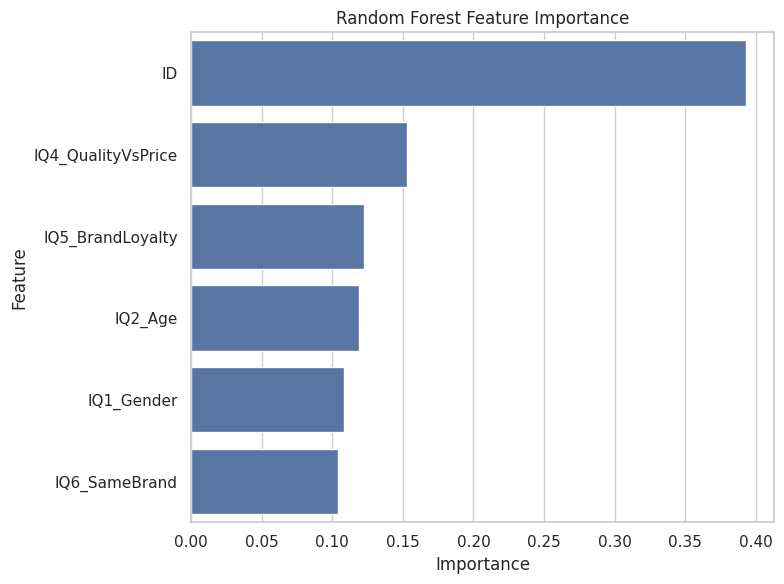

In [117]:
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importances.to_csv("random_forest_feature_importance.csv", index=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importances)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
plt.savefig("random_forest_importance_plot.png")
plt.close()


# 13. ROC Curve (Multiclass – One vs Rest)

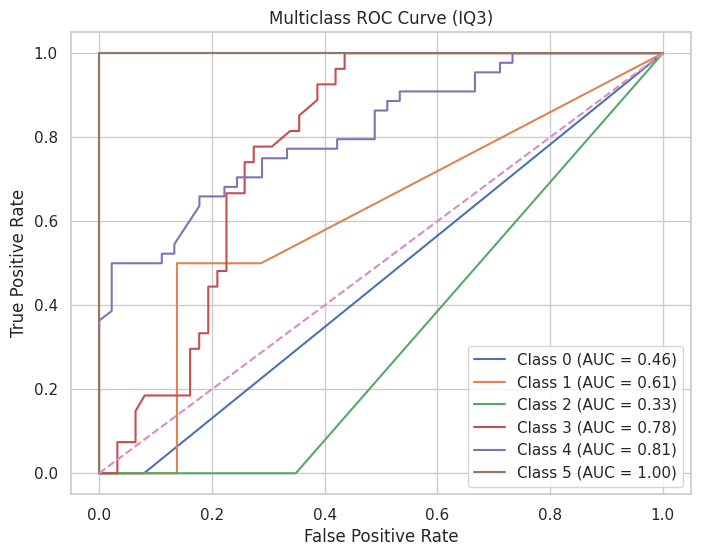

<Figure size 640x480 with 0 Axes>

In [118]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

# Predicted probabilities
y_score = rf_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (IQ3)")
plt.legend()
plt.grid(True)

# SHOW the plot
plt.show()

# OPTIONAL: Save the plot
plt.savefig("roc_curve_multiclass.png", dpi=300, bbox_inches='tight')


# 14. Additional Visualizations

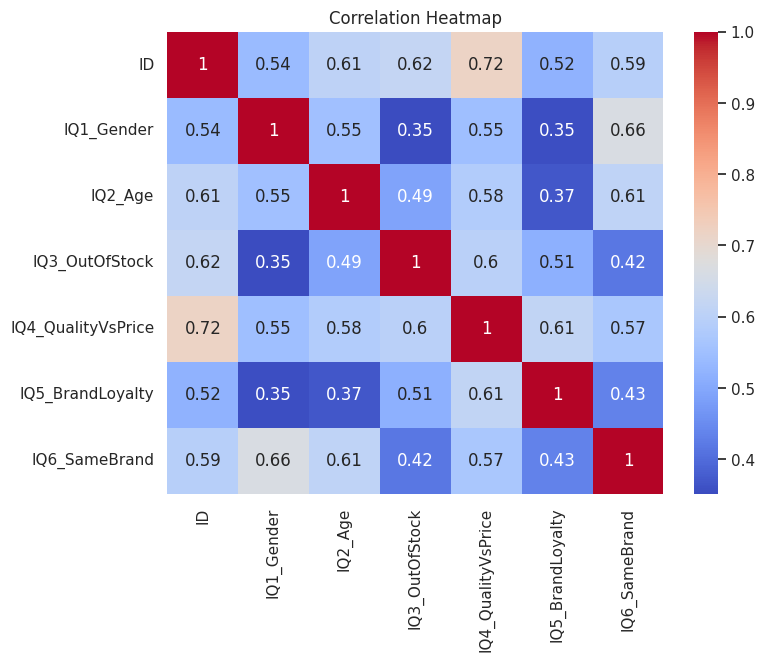

In [119]:
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
plt.savefig("correlation_heatmap.png")
plt.close()


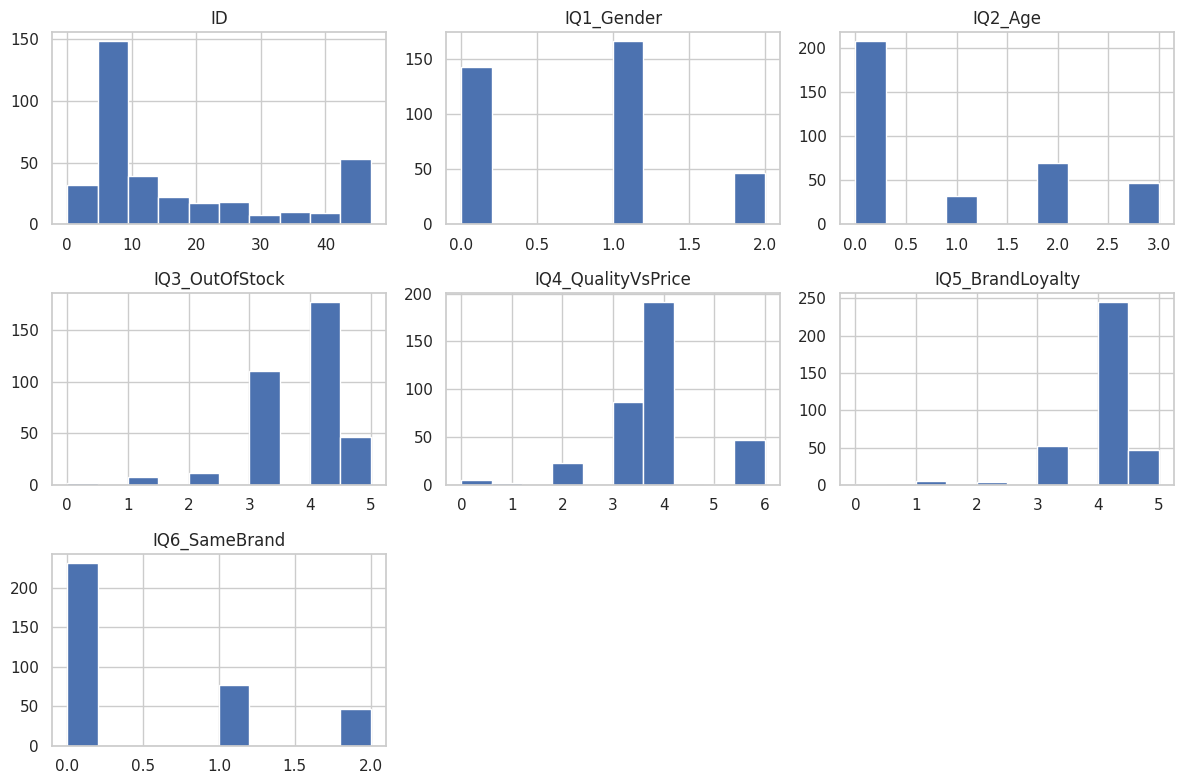

In [120]:
#Histogram Example
df_encoded.hist(figsize=(12,8))
plt.tight_layout()
plt.show()
plt.savefig("histograms_all_variables.png")
plt.close()


In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions first
y_pred = rf_model.predict(X_test) # Using rf_model as an example

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.6517
Precision: 0.6227
Recall   : 0.6517
F1 Score : 0.6352


In [122]:
print('Values of y_test:')
print(y_test)

Values of y_test:
191    4
158    4
185    4
14     3
114    3
      ..
207    4
225    4
151    2
250    4
320    5
Name: IQ3_OutOfStock, Length: 89, dtype: int64


In [123]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         3
           3       0.50      0.44      0.47        27
           4       0.68      0.77      0.72        44
           5       1.00      1.00      1.00        12

    accuracy                           0.65        89
   macro avg       0.36      0.37      0.37        89
weighted avg       0.62      0.65      0.64        89



**SVM**

In [124]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [125]:
svm_model = SVC(kernel='rbf', probability=True)

svm_model.fit(X_train, y_train)

SVC(probability=True)

In [126]:
y_pred_svm = svm_model.predict(X_test)

In [127]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.651685393258427

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         3
           3       0.50      0.56      0.53        27
           4       0.66      0.70      0.68        44
           5       1.00      1.00      1.00        12

    accuracy                           0.65        89
   macro avg       0.36      0.38      0.37        89
weighted avg       0.61      0.65      0.63        89


Confusion Matrix:

[[ 0  0  0  1  0  0]
 [ 0  0  0  0  2  0]
 [ 0  0  0  1  2  0]
 [ 0  0  0 15 12  0]
 [ 0  0  0 13 31  0]
 [ 0  0  0  0  0 12]]


In [128]:
y_prob_svm = svm_model.predict_proba(X_test)[:,1]

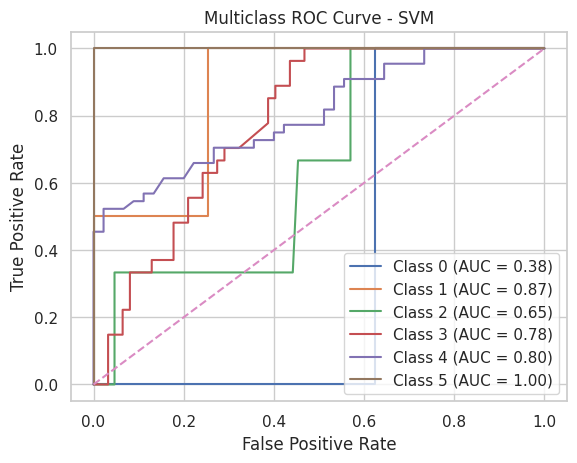

In [130]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
classes = sorted(y_test.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_prob_svm = svm_model.predict_proba(X_test)
for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - SVM")
plt.legend()
plt.show()

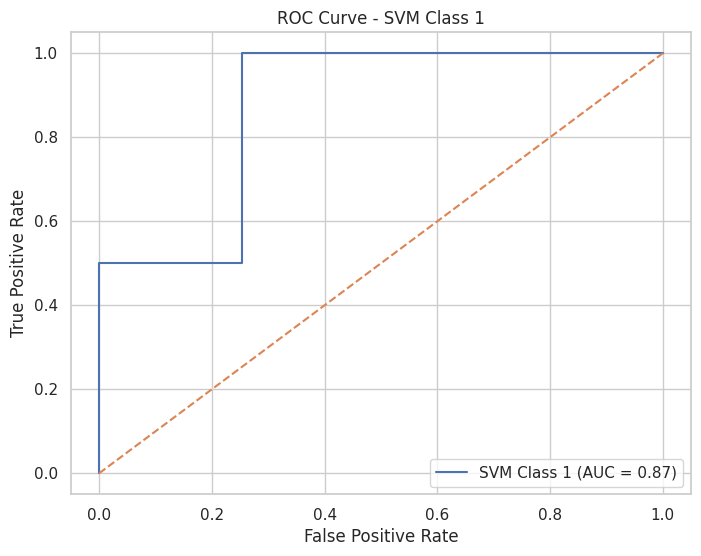

In [132]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Ensure y_test is binarized if not already from previous cells
# Assuming 'classes' and 'y_prob_svm' are available from the previous cell's execution context.
# If not, these lines would need to be uncommented and potentially adapted.
# classes = sorted(y_test.unique())
# y_test_bin = label_binarize(y_test, classes=classes)
# y_prob_svm = svm_model.predict_proba(X_test)

# For simplicity and to make this cell runnable, let's plot for one specific class (e.g., Class 1)
# We need to ensure y_test_bin and y_prob_svm are properly defined for this specific cell as well.
# Based on the kernel state, y_test_bin and y_prob_svm are available from N_df20T_FPjY execution.
# Let's choose a class, for example, the class at index 1 (which would be '1' if classes are 0,1,2,3,4,5).

# Define fpr_svm, tpr_svm, roc_auc_svm for a specific class (e.g., class 1, which corresponds to index 1 in y_test_bin and y_prob_svm)
# Check the unique values of y_test to determine the correct index for a desired class.
# For example, if you want to plot for the class that was at 'i=1' in the previous loop:
class_to_plot_index = 1 # Change this index if you want to plot a different class

# Ensure y_test_bin has been created from N_df20T_FPjY
if 'y_test_bin' not in locals():
    classes = sorted(y_test.unique())
    y_test_bin = label_binarize(y_test, classes=classes)

# Ensure y_prob_svm has been created from N_df20T_FPjY
if 'y_prob_svm' not in locals():
    y_prob_svm = svm_model.predict_proba(X_test)

fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, class_to_plot_index], y_prob_svm[:, class_to_plot_index])
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8,6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM Class {classes[class_to_plot_index]} (AUC = {roc_auc_svm:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - SVM Class {classes[class_to_plot_index]}")

plt.legend()
plt.show()

***. Neural Network (Keras)***

In [133]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [144]:
nn_model = Sequential()

n_classes_nn = len(np.unique(y_train)) # Get number of unique classes from y_train

nn_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(n_classes_nn, activation='softmax')) # Change output layer for multiclass

In [145]:
nn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Change loss function for multiclass integer labels
    metrics=['accuracy']
)

In [136]:
history = nn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.0223 - loss: -8.7560 - val_accuracy: 0.0000e+00 - val_loss: -15.2229
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0337 - loss: -19.4216 - val_accuracy: 0.0000e+00 - val_loss: -25.0485
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0214 - loss: -28.4595 - val_accuracy: 0.0000e+00 - val_loss: -35.1396
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0284 - loss: -40.7304 - val_accuracy: 0.0000e+00 - val_loss: -45.3534
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0159 - loss: -56.1235 - val_accuracy: 0.0000e+00 - val_loss: -56.9560
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0296 - loss: -67.3465 - val_accuracy: 0.0000e+00 - val_loss: -70.7421
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0310 - loss: -79.0493 - val_accuracy: 0.0000e+00 - val_loss: -86.8113
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0177 - 

In [137]:
loss, accuracy = nn_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0230 - loss: -806.3789
Test Accuracy: 0.02247191034257412


In [138]:
y_pred_nn = (nn_model.predict(X_test) > 0.5).astype(int)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [139]:
print(classification_report(y_test, y_pred_nn))
print(confusion_matrix(y_test, y_pred_nn))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.02      1.00      0.04         2
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00        27
           4       0.00      0.00      0.00        44
           5       0.00      0.00      0.00        12

    accuracy                           0.02        89
   macro avg       0.00      0.17      0.01        89
weighted avg       0.00      0.02      0.00        89

[[ 0  1  0  0  0  0]
 [ 0  2  0  0  0  0]
 [ 0  3  0  0  0  0]
 [ 0 27  0  0  0  0]
 [ 0 44  0  0  0  0]
 [ 0 12  0  0  0  0]]


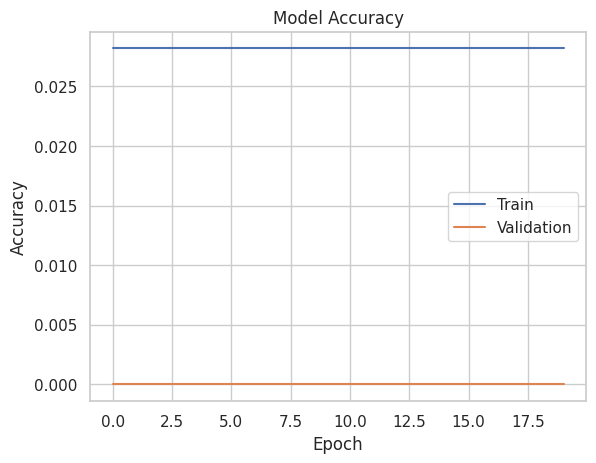

In [140]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [142]:
y_prob_nn = nn_model.predict(X_test).ravel()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


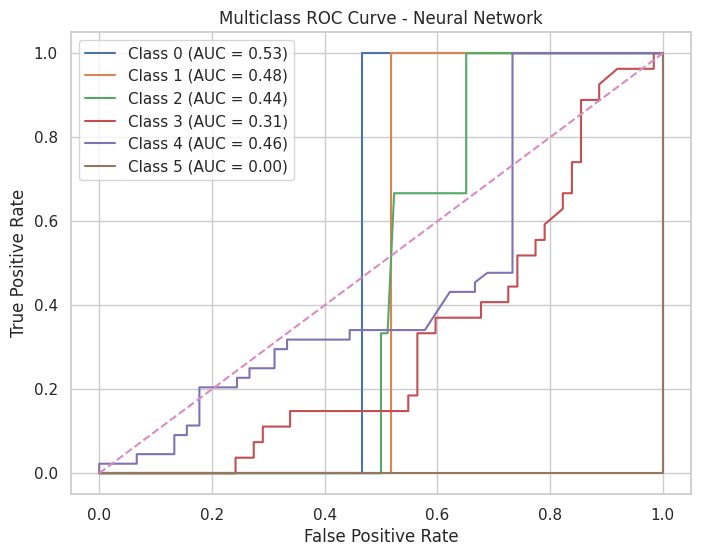

In [147]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_prob_nn = nn_model.predict(X_test)
plt.figure(figsize=(8,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_nn[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve - Neural Network")

plt.legend()
plt.show()

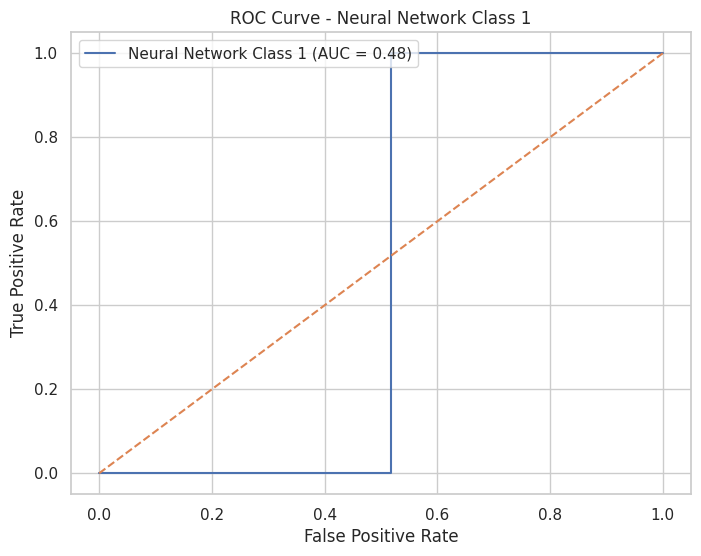

In [149]:
plt.figure(figsize=(8,6))



# Calculate fpr, tpr, and auc for a specific class (e.g., class at index 1)
class_to_plot_index = 1 # You can change this index to plot a different class
fpr_nn, tpr_nn, _ = roc_curve(y_test_bin[:, class_to_plot_index], y_prob_nn[:, class_to_plot_index])
roc_auc_nn = auc(fpr_nn, tpr_nn)

plt.plot(fpr_nn, tpr_nn, label=f"Neural Network Class {classes[class_to_plot_index]} (AUC = {roc_auc_nn:.2f})")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Neural Network Class {classes[class_to_plot_index]}")

plt.legend()
plt.show()

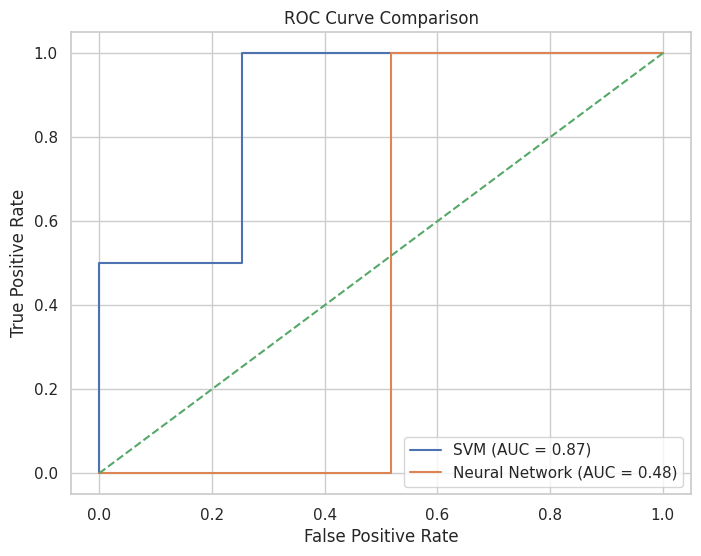

In [150]:
plt.figure(figsize=(8,6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {roc_auc_svm:.2f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {roc_auc_nn:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# 15. Save Processed Dataset

In [151]:
df_encoded.to_csv("processed_dataset.csv", index=False)



## 16.ZIP All Outputs


In [152]:
zipf = zipfile.ZipFile("IQ3_Consumer_Behavior_Results.zip", 'w', zipfile.ZIP_DEFLATED)

for folder, subfolders, files in os.walk("."):
    for file in files:
        if file.endswith((".csv", ".png")):
            zipf.write(os.path.join(folder, file))

zipf.close()

print("ZIP file created successfully!")


ZIP file created successfully!
